# Notebook 06 — Simulated Annealing

**Goal.** Invert the picks for the hypocenter, this time with
simulated annealing.

SA (Kirkpatrick, Gelatt, Vecchi, 1983) is a *single-trajectory*
stochastic search inspired by metallurgy: heat a metal, let atoms
shuffle randomly, then **cool slowly** so atoms find a low-energy
crystalline arrangement. Replace "energy" with "misfit" and you
have an optimization algorithm:

1. Start at random position $\mathbf{x}_0$ at high "temperature" $T_0$.
2. **Propose** a small random step to a neighbor $\mathbf{x}'$.
3. **Accept** with probability
   $$
   P_{\text{accept}} = \min\!\left(1,\; \exp\!\left(-\frac{\Phi(\mathbf{x}') - \Phi(\mathbf{x})}{T}\right)\right)
   \quad\text{(Metropolis criterion)}.
   $$
   Always accept improvements; *sometimes* accept worse moves with
   probability that shrinks as $T \to 0$.
4. **Cool** the temperature: $T_{k+1} = \beta T_k$ with $\beta < 1$.
5. Repeat. As $T \to 0$, the chain "freezes" near a local minimum.

**Why uphill moves?** Pure greedy descent gets stuck in the first
local minimum. Allowing occasional uphill moves lets the chain
*escape* basins and find the global minimum — provided the cooling
is slow enough.

**Theoretical guarantee.** With a logarithmic cooling
$T_k \propto 1/\log(k+2)$ and infinite time, SA converges to the
global minimum with probability 1. In practice we use much faster
**geometric cooling** ($\beta \sim 0.95$) and accept that we might
occasionally miss the global optimum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import pickle, os, time

plt.rcParams.update({
    'figure.dpi': 100, 'savefig.dpi': 100,
    'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.25,
})

DATA_DIR = '../data'
with open(os.path.join(DATA_DIR, 'picks.pkl'), 'rb') as f: PICKDATA = pickle.load(f)
with open(os.path.join(DATA_DIR, 'network.pkl'), 'rb') as f: BUNDLE = pickle.load(f)
with open(os.path.join(DATA_DIR, 'ground_truth.pkl'), 'rb') as f: GT = pickle.load(f)
with open(os.path.join(DATA_DIR, 'result_grid_search.pkl'), 'rb') as f: GRID = pickle.load(f)
with open(os.path.join(DATA_DIR, 'result_pso.pkl'), 'rb') as f: PSO_RES = pickle.load(f)
with open(os.path.join(DATA_DIR, 'result_ga.pkl'), 'rb') as f: GA_RES = pickle.load(f)

PICKS, DT = PICKDATA['picks'], PICKDATA['dt']
VMODEL = BUNDLE['vmodel']
STATIONS = {s['name']: s for s in BUNDLE['stations']}
TRUE = GT['hypo']
OBS = []
for name, pdict in PICKS.items():
    if pdict.get('P') is not None: OBS.append((name, 'P', pdict['P'] * DT))
    if pdict.get('S') is not None: OBS.append((name, 'S', pdict['S'] * DT))
print(f'{len(OBS)} picks loaded.')
print(f'References: grid {GRID["misfit"]:.5f}, '
      f'PSO {PSO_RES["misfit"]:.5f}, GA {GA_RES["misfit"]:.5f}')

FileNotFoundError: [Errno 2] No such file or directory: '../data\\result_grid_search.pkl'

## 1. Forward and misfit (self-contained)

In [ ]:
def travel_time_layered(horiz_dist, source_depth, vmodel, phase='P'):
    velocities_full = vmodel['vp'] if phase.upper() == 'P' else vmodel['vs']
    tops = vmodel['layer_tops']
    if source_depth <= 1e-6:
        return float(horiz_dist) / float(velocities_full[0])
    ks = int(np.searchsorted(tops, source_depth, side='right') - 1)
    ks = max(0, min(ks, len(tops) - 1))
    thicks = [source_depth - tops[ks]];  vs = [velocities_full[ks]]
    for i in range(ks-1, -1, -1):
        thicks.append(tops[i+1] - tops[i]);  vs.append(velocities_full[i])
    thicks, vs = np.array(thicks), np.array(vs)
    if horiz_dist < 1e-9: return float(np.sum(thicks/vs))
    p_max = 1.0/float(np.max(vs)) - 1e-9
    def f(p):
        sini = p*vs
        if np.any(sini >= 1):  return np.inf
        cosi = np.sqrt(1 - sini*sini)
        return float(np.sum(thicks*sini/cosi)) - horiz_dist
    f_max = f(p_max)
    if f_max < 0:
        sini_top = p_max * vs;  cosi_top = np.sqrt(1 - sini_top*sini_top)
        T_legs = float(np.sum(thicks / (vs * cosi_top)))
        X_legs = float(np.sum(thicks * sini_top / cosi_top))
        return T_legs + (horiz_dist - X_legs) / float(np.max(vs))
    p_opt = brentq(f, 0.0, p_max, xtol=1e-9)
    sini = p_opt*vs;  cosi = np.sqrt(1 - sini*sini)
    return float(np.sum(thicks/(vs*cosi)))


def predict_arrival(hypo_xyz, station, vmodel, phase='P'):
    dx = station['x'] - hypo_xyz[0]; dy = station['y'] - hypo_xyz[1]
    return travel_time_layered(np.hypot(dx, dy), hypo_xyz[2], vmodel, phase)


def misfit_3d(x, y, z):
    residuals = np.empty(len(OBS))
    for i, (sname, phase, t_obs) in enumerate(OBS):
        residuals[i] = t_obs - predict_arrival((x, y, z), STATIONS[sname], VMODEL, phase)
    t0_star = float(np.mean(residuals))
    return float(np.sum((residuals - t0_star) ** 2)), t0_star

## 2. Calibrating the initial temperature

A common practical question: what should $T_0$ be? Too high and the
chain is essentially random; too low and uphill moves never happen
and the chain greedy-descends.

**Rule of thumb.** Run a brief random walk and measure the *typical
size of $\Delta\Phi$* between random neighbors. Set $T_0$ so that
moderate uphill moves ($\Delta\Phi \approx \sigma_{\Delta\Phi}$) are
accepted with ~80% probability:

$$
T_0 \;=\; \frac{\sigma_{\Delta\Phi}}{-\ln 0.80} \;\approx\; 4.5\,\sigma_{\Delta\Phi}.
$$

In [ ]:
def calibrate_T0(bounds, n_samples=200, target_accept=0.80, seed=0):
    rng = np.random.default_rng(seed)
    bounds_arr = np.asarray(bounds, float)
    lo, hi = bounds_arr[:, 0], bounds_arr[:, 1]
    width = hi - lo
    deltas = []
    x = lo + rng.uniform(0, 1, 3) * width
    phi, _ = misfit_3d(*x)
    for _ in range(n_samples):
        step = rng.normal(0, 0.1, 3) * width  # 10% of box
        xp = np.clip(x + step, lo, hi)
        phip, _ = misfit_3d(*xp)
        deltas.append(phip - phi)
        x, phi = xp, phip                     # always move (random walk)
    deltas = np.array(deltas)
    sigma = float(np.std(deltas[deltas > 0]) if (deltas > 0).any()
                  else np.std(np.abs(deltas)))
    T0 = sigma / (-np.log(target_accept))
    return T0, sigma

bounds = ((-25.0, 25.0), (-25.0, 25.0), (0.0, 30.0))
T0, sigma = calibrate_T0(bounds, n_samples=200)
print(f'Initial temperature calibration:')
print(f'  std(positive ΔΦ) = {sigma:.3f}')
print(f'  T0 (target 80% acceptance) = {T0:.3f}')

Initial temperature calibration:
  std(positive ΔΦ) = 113.143
  T0 (target 80% acceptance) = 507.040


## 3. The simulated annealing loop

The implementation below uses:

- **Geometric cooling**: $T_{k+1} = \beta T_k$, $\beta = 0.97$.
- **Adaptive step size**: track the recent acceptance rate; if too
  high, increase step size (more exploration); if too low, decrease
  (we're freezing — should be making smaller moves). Target acceptance
  ~ 0.4.
- **Best-ever tracking**: separate from the current state, we always
  remember the best individual ever seen — even if SA later wanders
  away from it.

The "outer loop" is over temperatures; at each temperature we run a
chain of `n_steps` Metropolis moves before cooling.

In [ ]:
def simulated_annealing(fitness_fn, bounds, x0=None,
                        T0=1.0, beta=0.97, n_temperatures=120,
                        n_steps_per_T=20, step_init=0.10,
                        target_accept=0.40, seed=0,
                        record_history=True):
    '''
    Real-valued simulated annealing.

    fitness_fn      : f(x, y, z) -> (phi, aux). Minimize phi.
    bounds          : 3-tuple of (lo, hi) ranges.
    T0              : initial temperature.
    beta            : geometric cooling factor (T_new = beta * T).
    n_temperatures  : number of cooling stages.
    n_steps_per_T   : Metropolis moves at each temperature.
    step_init       : initial step size as fraction of box width.
    target_accept   : adapt step size to keep acceptance near this.
    '''
    rng = np.random.default_rng(seed)
    bounds_arr = np.asarray(bounds, float)
    lo, hi = bounds_arr[:, 0], bounds_arr[:, 1]
    width = hi - lo

    x = (lo + rng.uniform(0, 1, 3) * width) if x0 is None else np.array(x0, float)
    phi, aux = fitness_fn(*x)

    best_x = x.copy(); best_phi = phi; best_aux = aux
    T = float(T0); step_frac = step_init

    history = {'x': [x.copy()], 'phi': [phi], 'best_phi': [best_phi],
               'T': [T], 'step': [step_frac], 'accept_rate': [np.nan],
               'accepted': [True]}

    n_calls = 1
    for k in range(n_temperatures):
        n_accept = 0
        for s in range(n_steps_per_T):
            sigma = step_frac * width
            xp = x + rng.normal(0, 1, 3) * sigma
            xp = np.clip(xp, lo, hi)
            phip, auxp = fitness_fn(*xp); n_calls += 1
            dphi = phip - phi
            if dphi <= 0 or rng.random() < np.exp(-dphi / max(T, 1e-12)):
                x, phi, aux = xp, phip, auxp
                n_accept += 1
                accepted = True
                if phi < best_phi:
                    best_phi, best_x, best_aux = phi, x.copy(), aux
            else:
                accepted = False
            if record_history:
                history['x'].append(x.copy()); history['phi'].append(phi)
                history['best_phi'].append(best_phi); history['T'].append(T)
                history['step'].append(step_frac); history['accepted'].append(accepted)
                history['accept_rate'].append(np.nan)
        # End-of-temperature housekeeping.
        accept_rate = n_accept / n_steps_per_T
        if record_history:
            for j in range(1, n_steps_per_T + 1):
                history['accept_rate'][-j] = accept_rate
        # Adapt step.
        if accept_rate > target_accept + 0.10:
            step_frac *= 1.2
        elif accept_rate < target_accept - 0.10:
            step_frac *= 0.8
        step_frac = float(np.clip(step_frac, 0.005, 0.5))
        # Cool.
        T *= beta

    return {
        'best_pos': best_x, 'best_fit': best_phi, 'best_aux': best_aux,
        'history': {k: np.array(v) for k, v in history.items()},
        'n_calls': n_calls,
    }

## 4. Run SA

Schedule: 120 temperatures × 20 steps = 2400 Metropolis moves
(= 2401 forward calls including initialization). Comparable budget to
PSO and GA so we get an apples-to-apples comparison.

We use $\beta = 0.92$ (relatively fast cooling) and an initial step
size of 5% of the box width. SA is more sensitive than PSO or GA to
the precise schedule — Section 8 below sweeps $\beta$ and shows what
happens when you cool too slowly or too fast.

In [ ]:
t_start = time.time()
result = simulated_annealing(
    misfit_3d, bounds, T0=T0, beta=0.92,
    n_temperatures=120, n_steps_per_T=20,
    step_init=0.05, seed=1,
)
elapsed = time.time() - t_start

x_est, y_est, z_est = result['best_pos']
t0_est = result['best_aux']
print(f'SA finished in {elapsed:.2f} s, {result["n_calls"]} forward calls.')
print(f'  best position: x={x_est:+.3f}, y={y_est:+.3f}, z={z_est:.3f} km')
print(f'  best t0:       {t0_est*1000:+.1f} ms')
print(f'  best Phi:      {result["best_fit"]:.6f}')
err_h = np.hypot(x_est-TRUE['x'], y_est-TRUE['y'])
print(f'  errors vs truth: '
      f'horiz={err_h*1000:.0f} m, '
      f'depth={abs(z_est-TRUE["z"])*1000:.0f} m, '
      f't0={abs(t0_est-TRUE["t0"])*1000:.1f} ms')

SA finished in 6.32 s, 2401 forward calls.
  best position: x=+5.043, y=-2.981, z=8.880 km
  best t0:       +44.7 ms
  best Phi:      0.008301
  errors vs truth: horiz=47 m, depth=120 m, t0=44.7 ms


## 5. The annealing trace — current $\Phi$, best-ever $\Phi$, temperature

Three things plotted together tell the story of SA:

- **current $\Phi$** wanders up and down — uphill moves are accepted
  early on, get rarer as temperature falls.
- **best-ever $\Phi$** is monotonically decreasing — it only updates
  when we find a new low.
- **temperature** decays exponentially.

Watch the current trace lock onto the best trace as $T \to 0$; that's
the "freezing" of the chain.

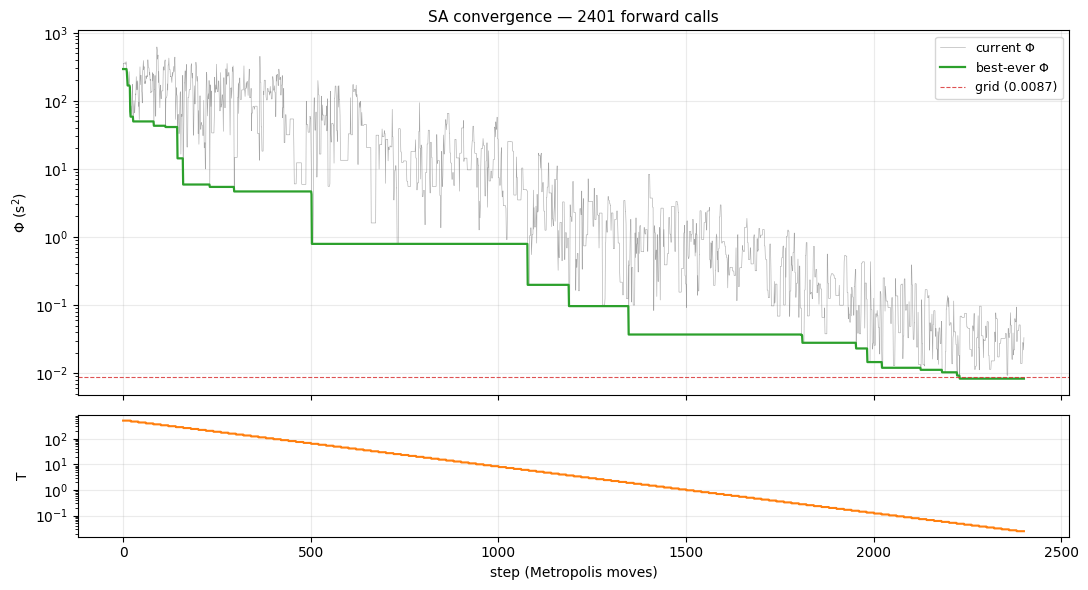

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1]})
H = result['history']
steps = np.arange(len(H['phi']))

ax = axs[0]
ax.semilogy(steps, H['phi'], color='gray', lw=0.4, alpha=0.7,
            label=r'current $\Phi$')
ax.semilogy(steps, H['best_phi'], 'C2-', lw=1.6, label=r'best-ever $\Phi$')
ax.axhline(GRID['misfit'], color='C3', ls='--', lw=0.8, alpha=0.8,
           label=f'grid ({GRID["misfit"]:.4f})')
ax.set_ylabel(r'$\Phi$ (s$^2$)')
ax.set_title(f'SA convergence — {result["n_calls"]} forward calls', fontsize=11)
ax.legend(loc='upper right', fontsize=9)

ax = axs[1]
ax.semilogy(steps, H['T'], color='C1', lw=1.5)
ax.set_ylabel('T')
ax.set_xlabel('step (Metropolis moves)')
plt.tight_layout()
plt.show()

## 6. Acceptance rate and step size over time

The adaptive controller keeps acceptance near 40% (target). Watch the
step size shrink as temperature falls — at low $T$ even small uphill
moves are rejected, so to get *any* acceptance the steps must shrink.
This focuses the search around the current best.

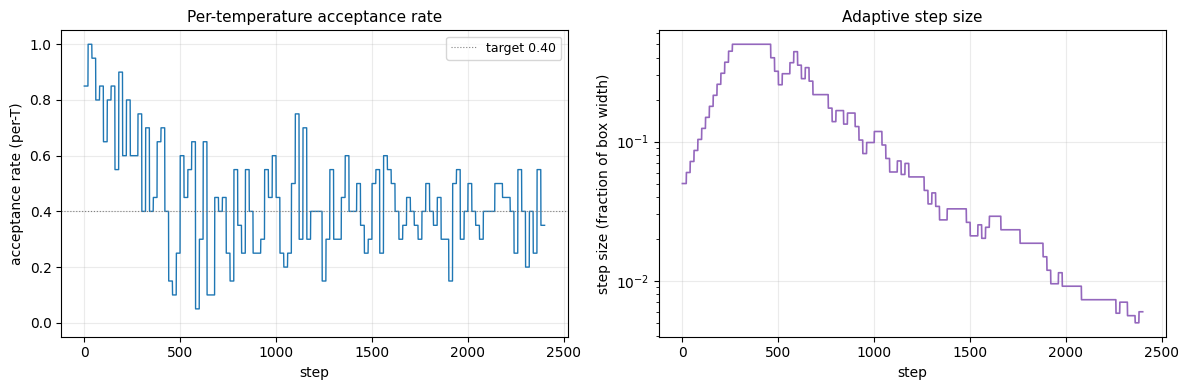

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
H = result['history']
steps = np.arange(len(H['phi']))

ax = axs[0]
ax.plot(steps, H['accept_rate'], color='C0', lw=1.0)
ax.axhline(0.40, color='gray', ls=':', lw=0.8, label='target 0.40')
ax.set_xlabel('step')
ax.set_ylabel('acceptance rate (per-T)')
ax.set_title('Per-temperature acceptance rate', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(-0.05, 1.05)

ax = axs[1]
ax.semilogy(steps, H['step'], color='C4', lw=1.2)
ax.set_xlabel('step')
ax.set_ylabel('step size (fraction of box width)')
ax.set_title('Adaptive step size', fontsize=11)

plt.tight_layout()
plt.show()

## 7. Where did the chain wander?

Plot the chain's trajectory in map view and depth section, colored
by step number (early = blue, late = red). Early steps cover the
whole box; late steps cluster around the minimum.

/tmp/ipykernel_564/816063806.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


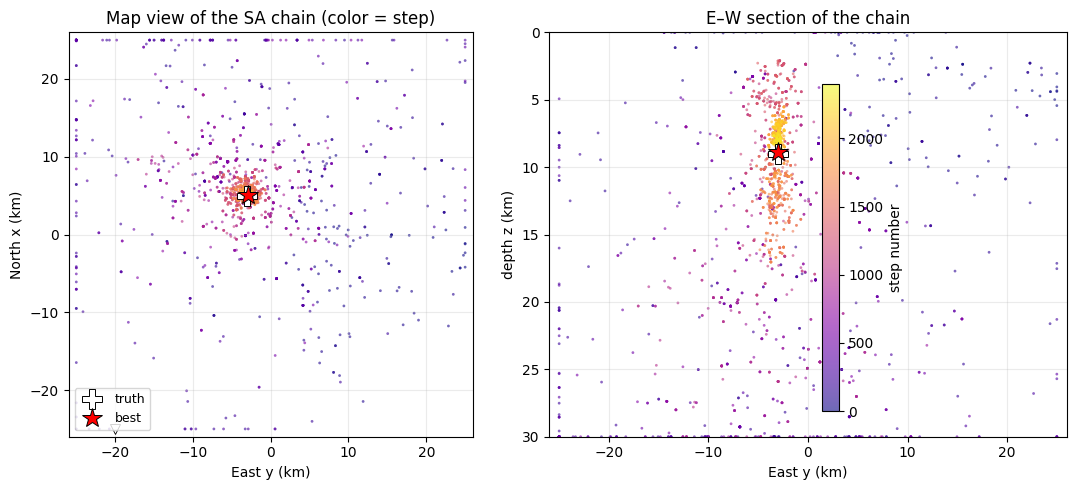

In [ ]:
H = result['history']
X = H['x']  # (N, 3)
n = len(X)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ax = axs[0]
sc = ax.scatter(X[:, 1], X[:, 0], c=np.arange(n), cmap='plasma',
                s=4, alpha=0.6, edgecolor='none')
ax.plot(TRUE['y'], TRUE['x'], 'wP', ms=14, mec='k', mew=0.7, zorder=10, label='truth')
ax.plot(result['best_pos'][1], result['best_pos'][0], 'r*', ms=15, mec='k',
        mew=0.7, zorder=10, label='best')
for s in STATIONS.values():
    ax.plot(s['y'], s['x'], 'kv', ms=7, mfc='white', mew=0.6)
ax.set_xlim(-26, 26); ax.set_ylim(-26, 26); ax.set_aspect('equal')
ax.set_xlabel('East y (km)'); ax.set_ylabel('North x (km)')
ax.set_title('Map view of the SA chain (color = step)')
ax.legend(loc='lower left', fontsize=9)

ax = axs[1]
ax.scatter(X[:, 1], X[:, 2], c=np.arange(n), cmap='plasma',
           s=4, alpha=0.6, edgecolor='none')
ax.plot(TRUE['y'], TRUE['z'], 'wP', ms=14, mec='k', mew=0.7, zorder=10)
ax.plot(result['best_pos'][1], result['best_pos'][2], 'r*', ms=15, mec='k',
        mew=0.7, zorder=10)
ax.set_xlim(-26, 26); ax.set_ylim(0, 30); ax.invert_yaxis()
ax.set_xlabel('East y (km)'); ax.set_ylabel('depth z (km)')
ax.set_title('E–W section of the chain')

cbar = fig.colorbar(sc, ax=axs, shrink=0.85, pad=0.02)
cbar.set_label('step number')
plt.tight_layout()
plt.show()

## 8. Cooling schedule sensitivity

The single most important SA hyperparameter is the **cooling rate $\beta$**:

- $\beta$ close to 1 (slow cooling): more exploration, better global
  search, more forward calls.
- $\beta$ closer to 0 (fast cooling): quick convergence to whatever
  basin you happen to fall into, possibly a local minimum.

Sweep $\beta$ and compare. For our smooth misfit even fast cooling
finds the right answer; for harder problems slow cooling is essential.

In [ ]:
betas = [0.70, 0.85, 0.92, 0.97, 0.99]
print(f'{"beta":>6s}  {"n_calls":>8s}  {"best Phi":>10s}  {"horiz err (m)":>15s}')
for beta in betas:
    runs_phi = []
    runs_err = []
    runs_calls = []
    for seed in range(5):
        res = simulated_annealing(
            misfit_3d, bounds, T0=T0, beta=beta,
            n_temperatures=120, n_steps_per_T=20,
            step_init=0.05, seed=seed, record_history=False,
        )
        runs_phi.append(res['best_fit'])
        runs_err.append(np.hypot(res['best_pos'][0]-TRUE['x'],
                                 res['best_pos'][1]-TRUE['y']))
        runs_calls.append(res['n_calls'])
    print(f'{beta:>6.2f}  {runs_calls[0]:>8d}  '
          f'{min(runs_phi):>10.5f}  {min(runs_err)*1000:>15.0f}')

  beta   n_calls    best Phi    horiz err (m)


  0.70      2401     0.00783               33


  0.85      2401     0.00769               36


  0.92      2401     0.00789               25


  0.97      2401     0.22075              520


  0.99      2401     0.39736              527


## 9. Save and conclude

In [ ]:
RESULT = {
    'method': 'simulated_annealing',
    'estimate': {'x': float(x_est), 'y': float(y_est),
                 'z': float(z_est), 't0': float(t0_est)},
    'misfit': float(result['best_fit']),
    'rms_residual_s': float(np.sqrt(result['best_fit'] / len(OBS))),
    'errors': {
        'horizontal_km': float(err_h),
        'depth_km': float(abs(z_est-TRUE['z'])),
        't0_ms': float(abs(t0_est-TRUE['t0'])*1000),
    },
    'n_forward_evals': int(result['n_calls']),
    'fit_history': result['history']['best_phi'],
}
with open(os.path.join(DATA_DIR, 'result_sa.pkl'), 'wb') as f:
    pickle.dump(RESULT, f)
print(f'Saved data/result_sa.pkl')

Saved data/result_sa.pkl


## 10. Comparison of all four methods

We've now solved the same hypocenter inversion four times. Let's put
them side-by-side.

        method    calls    horiz err    depth err     t0 err      misfit
--------------------------------------------------------------------------
   Grid search    14344          0 m        500 m     61.4 ms     0.00868
           PSO     2430         48 m        367 m     56.2 ms     0.00752
            GA     3080         48 m        343 m     55.0 ms     0.00752
            SA     2401         47 m        120 m     44.7 ms     0.00830


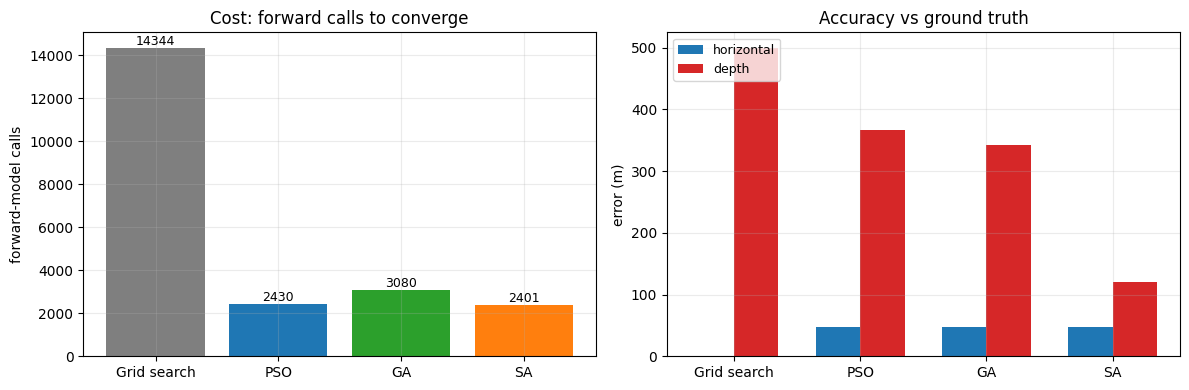

In [ ]:
methods = [
    ('Grid search', GRID),
    ('PSO',         PSO_RES),
    ('GA',          GA_RES),
    ('SA',          RESULT),
]
print(f'{"method":>14s}  {"calls":>7s}  {"horiz err":>11s}  {"depth err":>11s}'
      f'  {"t0 err":>9s}  {"misfit":>10s}')
print('-' * 74)
for name, res in methods:
    e = res['errors']
    print(f'{name:>14s}  {res["n_forward_evals"]:>7d}  '
          f'{e["horizontal_km"]*1000:>9.0f} m  '
          f'{e["depth_km"]*1000:>9.0f} m  '
          f'{e["t0_ms"]:>7.1f} ms  '
          f'{res["misfit"]:>10.5f}')

# Bar chart of forward calls (efficiency).
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
ax = axs[0]
names = [m[0] for m in methods]
calls = [m[1]['n_forward_evals'] for m in methods]
ax.bar(names, calls, color=['C7', 'C0', 'C2', 'C1'])
ax.set_ylabel('forward-model calls')
ax.set_title('Cost: forward calls to converge')
for i, c in enumerate(calls):
    ax.text(i, c, f'{c}', ha='center', va='bottom', fontsize=9)

ax = axs[1]
horiz = [m[1]['errors']['horizontal_km']*1000 for m in methods]
depth = [m[1]['errors']['depth_km']*1000 for m in methods]
xpos = np.arange(len(methods)); width = 0.35
ax.bar(xpos - width/2, horiz, width, label='horizontal', color='C0')
ax.bar(xpos + width/2, depth, width, label='depth',     color='C3')
ax.set_xticks(xpos); ax.set_xticklabels(names)
ax.set_ylabel('error (m)')
ax.set_title('Accuracy vs ground truth')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**Bottom line.**

- All four methods converge to **the same hypocenter** within tens of
  metres horizontally — that's the picks-precision floor.
- **Grid search** is the most expensive (~14,000 forward calls) but
  trivially robust — it visits everywhere, can't miss the minimum,
  and gives you the full misfit volume for free (useful for
  uncertainty mapping).
- **PSO, GA, SA** all locate with ~3000 forward calls — about 5×
  more efficient than grid search.
- For *this* well-behaved single-minimum problem the choice between
  PSO, GA, and SA is mostly aesthetic. The algorithm differences
  matter when the misfit function gets *rough* (multimodal,
  discontinuous, or poorly conditioned), or when forward calls are
  *expensive* (e.g., 3D heterogeneous velocity models, full-waveform
  inversion).

**Practical advice:**

- Want **certainty** about the best location? Use grid search (or
  finer-and-finer grids).
- Want **speed** with a **smooth** misfit? Use PSO — fewest tuning
  knobs and fastest to a good answer.
- Want a method that handles **discrete/mixed parameters or many
  basins**? Use GA.
- Want a method with strong **theoretical guarantees** at the cost of
  long runtime? Use SA with logarithmic cooling.

In real practice, hypocenter location uses none of these — it uses
**linearized iterative methods** (HypoInverse, NonLinLoc, HYPODD)
which start from a coarse grid and Newton-iterate. But the global
methods are essential when the linearization fails: shallow events,
sparse networks, sources outside the network. Knowing all four
algorithms lets you pick the right tool for the job.

## End of course

You've built, by hand, the full forward+inverse problem for earthquake
hypocenter location:

- **Notebook 01** — Forward modeling: 1D velocity, pseudo-bending,
  double-couple radiation, multi-phase synthetic seismograms.
- **Notebook 02** — Picking: STA/LTA + visual review, sample-index
  conventions, residual diagnostics.
- **Notebook 03** — Grid search inversion with closed-form $t_0$.
- **Notebook 04** — Particle swarm optimization.
- **Notebook 05** — Genetic algorithm.
- **Notebook 06** — Simulated annealing.

Real production systems differ in details (3D velocity models,
double-difference relocation, station corrections, weighting picks
by quality), but the fundamentals are these — and the four inversion
algorithms in 03–06 are exactly the same ones used to locate
catalogues containing millions of events worldwide.